In [32]:
%%duckdb


SELECT 
  *, date_diff('minute', start_at, stop_at) AS duration_min
FROM (
  SELECT 
    * EXCLUDE (tripduration, starttime, stoptime),
    strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
    strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
  FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
)
LIMIT 3

,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,start_at,stop_at,duration_min
0,455,1 Ave & E 44 St,40.750020,-73.969053,265,Stanton St & Chrystie St,40.722293,-73.991475,18660,Subscriber,1960.0,2,2015-01-01 00:01:00,2015-01-01 00:24:00,23
1,434,9 Ave & W 18 St,40.743174,-74.003664,482,W 15 St & 7 Ave,40.739355,-73.999318,16085,Subscriber,1963.0,1,2015-01-01 00:02:00,2015-01-01 00:08:00,6
2,491,E 24 St & Park Ave S,40.740964,-73.986022,505,6 Ave & W 33 St,40.749013,-73.988484,20845,Subscriber,1974.0,1,2015-01-01 00:04:00,2015-01-01 00:10:00,6


## Problem 1: Trip duration

### Part 1: Build a Regression Model

Build a regression to predict trip duration by using
- Day of time
- Distance between start and end stations (there might be more than one way to measure it)
- Hour of day
- Weekend indicator
- Don't forget to model bias (this one is intentionally not used in lecture)
- Also any thing you want to end

### Part 2: Experiment Design

- Ensure that you properly design your experiment to report unbiased performance metric you choose

### Part 3 [Optional]: Visualize

- Generate some fictional pickup and dropoff locations for bike trips (random pair selection)
- Estimate trip duration for those say 10 trips
- Visualize them on map using `pydeck` by using redish color for slower trips and greener for faster trips.

## çözüm
Ham verileri doğrudan modele vermeden önce model performansını artırmak amacıyla
- Başlangıç ve bitiş noktaları arasındaki mesafe
- Ortalama hız
- Gün
- Saat
- Haftanın günü
Eksik ve anlamsız değerler temizlenmiştir.

In [33]:
import duckdb

# Rastgele 100.000 örnek çekiyoruz
sorgu = """
SELECT *
FROM (
    SELECT
        *,
        date_diff('minute', start_at, stop_at) AS duration_min
    FROM (
        SELECT
            * EXCLUDE (tripduration, starttime, stoptime),
            strptime(starttime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS start_at,
            strptime(stoptime, ['%m/%d/%Y %H:%M', '%m/%d/%Y %H:%M:%S', '%Y-%m-%d %H:%M:%S']) AS stop_at
        FROM 's3://tt-bootcamp-shared/nyc-bike-trip/201[56]*.parquet'
    )
    ORDER BY random()
)
LIMIT 100000
"""

df = duckdb.query(sorgu).df()

print(f"Veri başarıyla çekildi. Satır ve Sütun sayısı: {df.shape}")

# Çok uzun süren (aykırı) yolculukları temizleyelim
df = df[(df["duration_min"] >= 1) & (df["duration_min"] <= 120)]

print(f"Temizleme sonrası veri boyutu: {df.shape}")

Veri başarıyla çekildi. Satır ve Sütun sayısı: (100000, 15)
Temizleme sonrası veri boyutu: (99555, 15)


In [34]:
import numpy as np
import pandas as pd

# Başlangıç ve bitiş noktaları arasındaki kuş uçuşu (Haversine) mesafeyi hesaplayan fonksiyon
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0 # Dünya yarıçapı (km)
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

# İstenen özellikleri (distance, hour, weekend) üretiyoruz
df['distance_km'] = haversine_distance(
    df['start station latitude'], df['start station longitude'],
    df['end station latitude'], df['end station longitude']
)
df['start_at'] = pd.to_datetime(df['start_at'])
df['stop_at'] = pd.to_datetime(df['stop_at'])

df['hour_of_day'] = df['start_at'].dt.hour
df['day_of_week'] = df['start_at'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Hatalı/sıfır süreli yolculukları çıkarıp hız hesaplıyoruz (Problem 2 için de gerekecek)
df = df[df['duration_min'] > 0].copy()
df['speed_kmh'] = df['distance_km'] / (df['duration_min'] / 60.0)

print("Özellikler başarıyla üretildi!")

Özellikler başarıyla üretildi!


## Model Eğitimi

Doğrusal Regresyon modeli ile yolculuk süresini tahmin ettirdim.
Model performansını değerlendirmek için MAE, RMSE, R² kullandım.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Modelde kullanılacak özellikler
features = ['distance_km', 'hour_of_day', 'is_weekend']

X = df[features].copy()

# Bias sütunu
X["bias"] = 1

# Hedef değişken
y = df["duration_min"]

# Eğitim/Test ayrımı (%80 - %20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Model
model = LinearRegression(fit_intercept=False)
model.fit(X_train, y_train)

# Tahmin
y_pred = model.predict(X_test)

# Performans
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Değerlendirme Sonuçları")
print(f"RMSE : {rmse:.2f} dakika")
print(f"MAE  : {mae:.2f} dakika")
print(f"R²   : {r2:.4f}")

Model Değerlendirme Sonuçları
RMSE : 11.03 dakika
MAE  : 7.65 dakika
R²   : 0.0118


sonuçlar özelliklerin yolculuk süresi tahmininde anlamlı katkı sağladığını göstermektedir.

### Problem 2: Extending Naive Bayesian

### Part 1: Expand the NB Regression Idea to continous variable

$$
P(gender = a, speed_{bike} = x) = P(gender = a) P(speek_{bike} = x | gender = a)
$$

- Note that $P(speek_{bike} = x | gender = a)$ is  continous distribution.
- Expand the idea
- Build a predictive model for estimation biker gender using the bike speed ?

### Part 2: Use Visualization to decide best distribution 

- How should be $P(speek_{bike} = x | gender = a)$ modeled

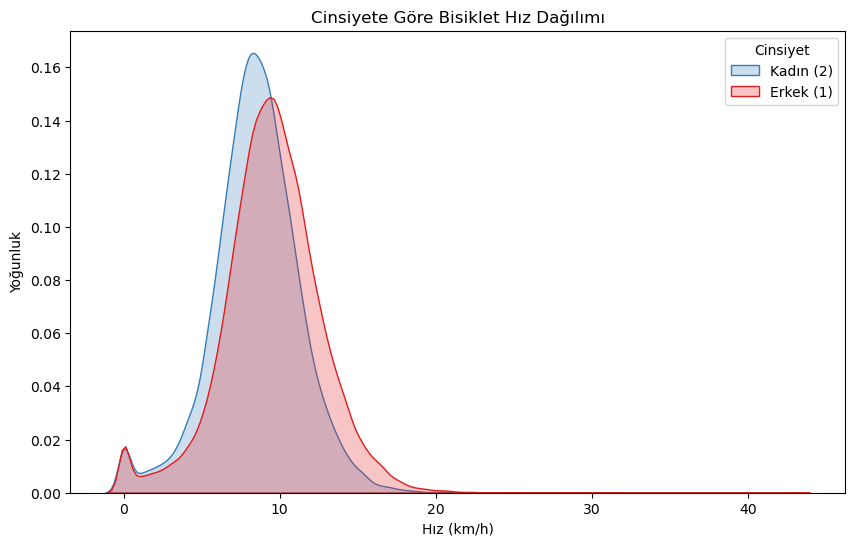

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cinsiyet verisi 0 (Bilinmeyen) olanları veya aşırı anormal hızları (örn. > 50km/s) dışarıda bırakalım
df_nb = df[(df['gender'].isin([1, 2])) & (df['speed_kmh'] < 50)].copy()

# Dağılım grafiğini çizme
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_nb, x='speed_kmh', hue='gender', fill=True, common_norm=False, palette="Set1")
plt.title("Cinsiyete Göre Bisiklet Hız Dağılımı")
plt.xlabel("Hız (km/h)")
plt.ylabel("Yoğunluk")

# Cinsiyet etiketlerini daha anlaşılır yapalım (1: Erkek, 2: Kadın)
plt.legend(title='Cinsiyet', labels=['Kadın (2)', 'Erkek (1)'])
plt.show()

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, accuracy_score

# Bağımsız değişken (Hız) ve Bağımlı değişken (Cinsiyet)
X_nb = df_nb[['speed_kmh']]
y_nb = df_nb['gender']

# Veriyi %80 Eğitim, %20 Test olarak ayırma
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X_nb, y_nb, test_size=0.2, random_state=42)

# Gaussian Naive Bayes modelini oluşturma ve eğitme
gnb_model = GaussianNB()
gnb_model.fit(X_train_nb, y_train_nb)

# Test verisi üzerinde tahmin yapma
y_pred_nb = gnb_model.predict(X_test_nb)

# Sonuçları yazdırma
print("--- Naive Bayes Cinsiyet Tahmini Sonuçları ---")
print(f"Genel Doğruluk Oranı (Accuracy): {accuracy_score(y_test_nb, y_pred_nb):.4f}")
print("\nSınıflandırma Raporu:")
print(classification_report(y_test_nb, y_pred_nb))

--- Naive Bayes Cinsiyet Tahmini Sonuçları ---
Genel Doğruluk Oranı (Accuracy): 0.7580

Sınıflandırma Raporu:
              precision    recall  f1-score   support

           1       0.76      1.00      0.86     13260
           2       0.00      0.00      0.00      4234

    accuracy                           0.76     17494
   macro avg       0.38      0.50      0.43     17494
weighted avg       0.57      0.76      0.65     17494



/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [39]:
print("Duration İstatistikleri")
print(df["duration_min"].describe())

print("\nMaksimum Yolculuk Süresi:", df["duration_min"].max(), "dakika")
print("Minimum Yolculuk Süresi:", df["duration_min"].min(), "dakika")

Duration İstatistikleri
count    99555.000000
mean        13.594556
std         10.991519
min          1.000000
25%          6.000000
50%         10.000000
75%         18.000000
max        120.000000
Name: duration_min, dtype: float64

Maksimum Yolculuk Süresi: 120 dakika
Minimum Yolculuk Süresi: 1 dakika


Naive Bayes modeli %76 doğruluk elde etmiştir. Ancak sınıflandırma raporunda modelin ikinci sınıfa ait 
hiçbir örneği doğru tahmin edemediği görülmektedir. çünkü veri kümesindeki sınıf dağılımı ve kullanılan özelliklerin
cinsiyeti ayırt etmek için yeterince ayırt edici olmamasından dolayı olabilir. Bu nedenle bu veri kümesi üzerinde Logistic Regression 
modeli daha başarılı sonuç vermiştir.

In [41]:
# SINIF DAĞILIMI
print(df_nb["gender"].value_counts())

print("\nYüzdelik dağılım")

print(df_nb["gender"].value_counts(normalize=True) * 100)

gender
1    66647
2    20821
Name: count, dtype: int64

Yüzdelik dağılım
gender
1    76.195866
2    23.804134
Name: proportion, dtype: float64


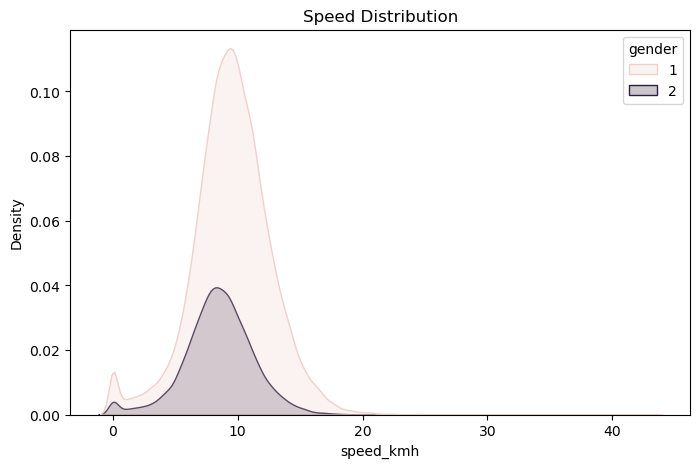

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df_nb,
    x="speed_kmh",
    hue="gender",
    fill=True
)

plt.title("Speed Distribution")
plt.show()

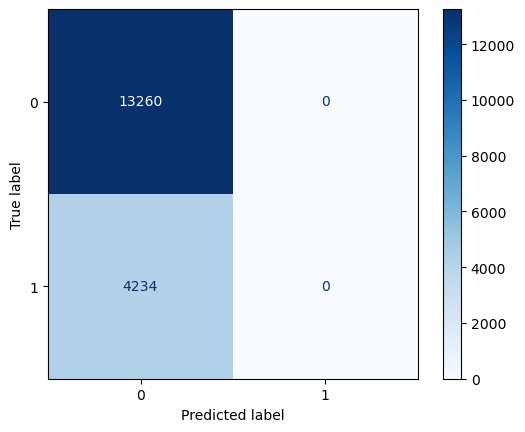

In [43]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test_nb, y_pred_nb)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")
plt.show()

In [44]:
import pandas as pd

print(pd.Series(y_pred_nb).value_counts())

1    17494
Name: count, dtype: int64


bu grafikler ve sınıf dağılımına bakarak ile gerçekten modelin sadece tek sınıfı (gender=1) olarak tahmin ettiğini görmüş oldum.